**Data Preprocessing Techniques**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

In [19]:
warnings.filterwarnings('ignore', category = DeprecationWarning)
warnings.filterwarnings('ignore', category = FutureWarning)

In [3]:
uber_df = pd.read_csv("uberdrive.csv")

In [3]:
uber_df.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [4]:
uber_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   START_DATE*  1156 non-null   object 
 1   END_DATE*    1155 non-null   object 
 2   CATEGORY*    1155 non-null   object 
 3   START*       1155 non-null   object 
 4   STOP*        1155 non-null   object 
 5   MILES*       1156 non-null   float64
 6   PURPOSE*     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [12]:
uber_df.columns = (uber_df.columns
                   .str.replace('*','', regex=False)
                   .str.replace(' ','')
                   .str.lower()
                   .str.strip())

In [13]:
uber_df.columns

Index(['start_date', 'end_date', 'category', 'start', 'stop', 'miles',
       'purpose'],
      dtype='object')

In [14]:
uber_df['start_date'] = pd.to_datetime(uber_df['start_date'], errors='coerce')
uber_df['end_date'] = pd.to_datetime(uber_df['end_date'], errors='coerce')

In [15]:
uber_df = uber_df.dropna(subset=['start_date', 'end_date'])

In [9]:
uber_df['purpose'] = uber_df['purpose'].fillna('Personal')

In [10]:
uber_df['category'].value_counts()

category
Business    407
Personal     13
Name: count, dtype: int64

In [17]:
uber_df['hour'] = uber_df['start_date'].dt.hour
uber_df['weekday'] = uber_df['start_date'].dt.day_name()
uber_df['day'] = uber_df['start_date'].dt.day
uber_df['month'] = uber_df['start_date'].dt.month

C:\Users\Ahamed\AppData\Local\Temp\ipykernel_20868\199920731.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uber_df['hour'] = uber_df['start_date'].dt.hour
C:\Users\Ahamed\AppData\Local\Temp\ipykernel_20868\199920731.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uber_df['weekday'] = uber_df['start_date'].dt.day_name()
C:\Users\Ahamed\AppData\Local\Temp\ipykernel_20868\199920731.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

In [ ]:
uber_df['is_weekend'] = uber_df['start_date'].dt.dayofweek >= 5

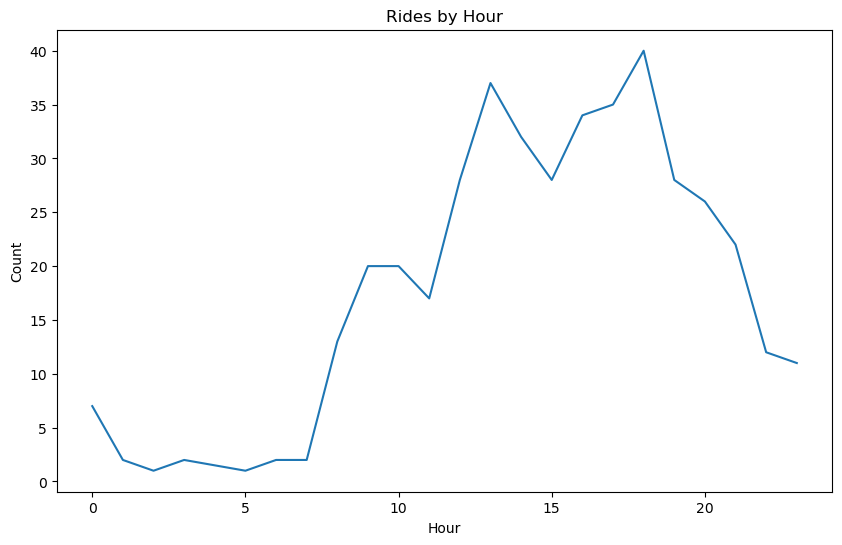

In [20]:
plt.figure(figsize=(10,6))
hour_data = uber_df.groupby('hour').size().reset_index(name='count')
sns.lineplot(x='hour', y='count', data=hour_data)
plt.title("Rides by Hour")
plt.xlabel('Hour')
plt.ylabel('Count')
plt.show()

**Insight:**
*Ride demand is very low during early morning hours (midnight to 6 AM) and there is a gradual increase in rides starting from morning.
The highest ride activity occurs during afternoon to evening hours (around 12 PM to 6 PM) and after evening, ride demand starts decreasing again towards night.*

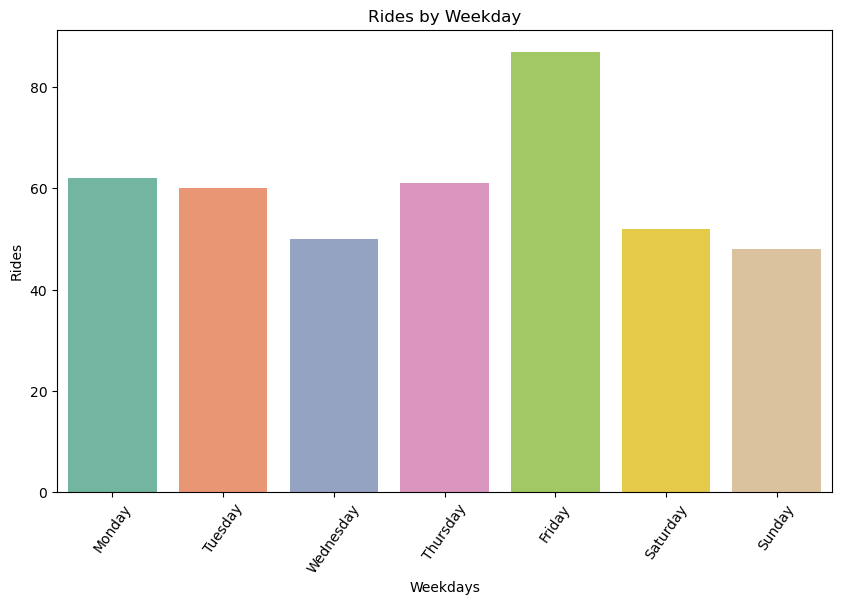

In [22]:
plt.figure(figsize=(10,6))
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sns.countplot(x='weekday', data=uber_df, palette = 'Set2', order = order)
plt.title("Rides by Weekday")
plt.xticks(rotation=55)
plt.xlabel('Weekdays')
plt.ylabel('Rides')
plt.show()

**Insights:** 
*Ride demand is highest on Friday and generally higher during weekdays, while weekends especially on Sunday show lower activity. This indicates that Uber rides are primarily used for work-related purpose only as weekdays are the working days*

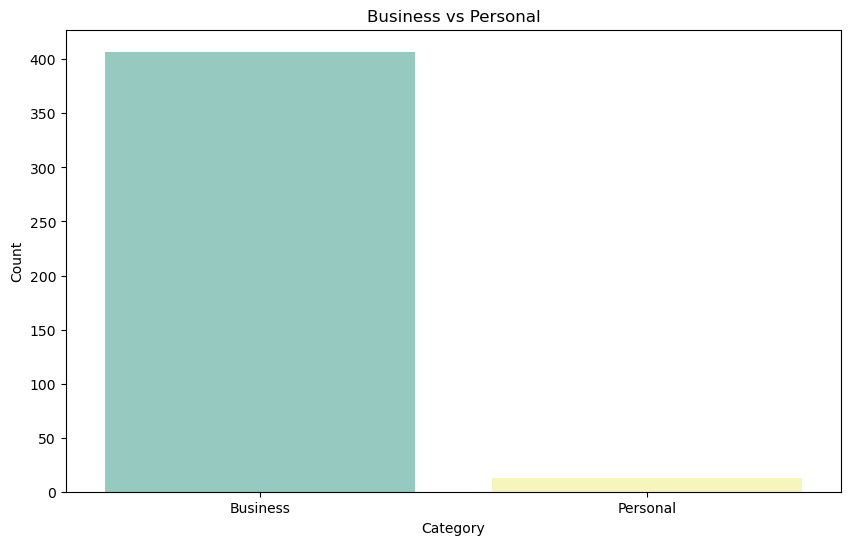

In [26]:
plt.figure(figsize=(10,6))
sns.countplot(x='category', data=uber_df, palette = 'Set3')
plt.title("Business vs Personal")
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

**Insights:**
*Business rides significantly outnumber personal rides, indicating that the dataset is dominated by work-related travel usage.*

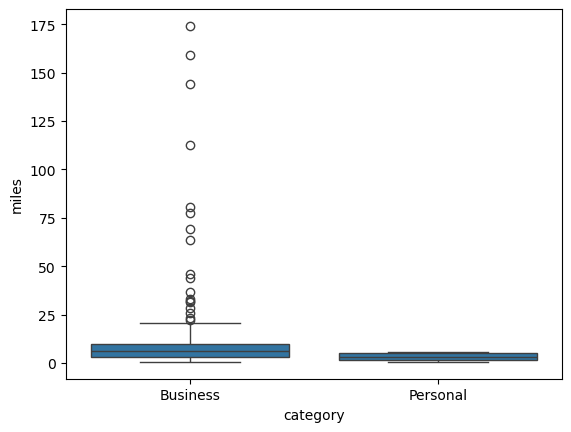

In [29]:
sns.boxplot(x='category', y='miles', data=uber_df)
plt.show()

**Insight:**
*Business rides generally have higher distance compared to personal rides.The spread (variation) of distances is much wider for business trips,indicating that business rides include both short and long-distance travel.*
*Personal rides are mostly short-distance with less variation and there are several outliers in business rides, showing some extremely long trips.*
*This suggests that business usage involves more diverse and longer travel needs compared to personal usage.*

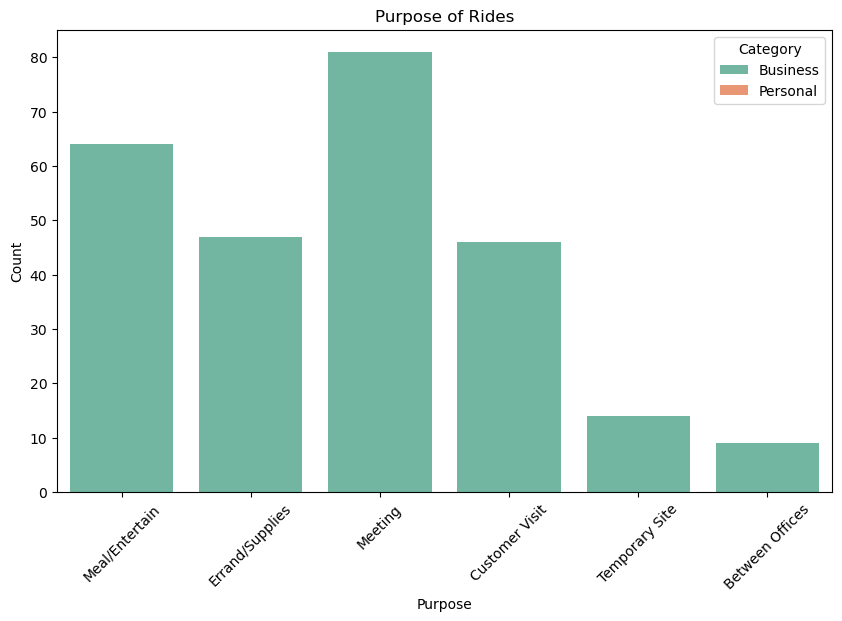

In [28]:
plt.figure(figsize=(10,6))
sns.countplot(x='purpose', data=uber_df, hue='category', palette='Set2')
plt.xticks(rotation=45)
plt.title("Purpose of Rides")
plt.xlabel("Purpose")
plt.ylabel("Count")
plt.legend(title="Category")
plt.show()

**Insights:**
*Meetings are the most common purpose for rides, followed by meals and errands. Business-related activities dominate the dataset, while personal rides are minimal, indicating that Uber is primarily used for professional purposes*

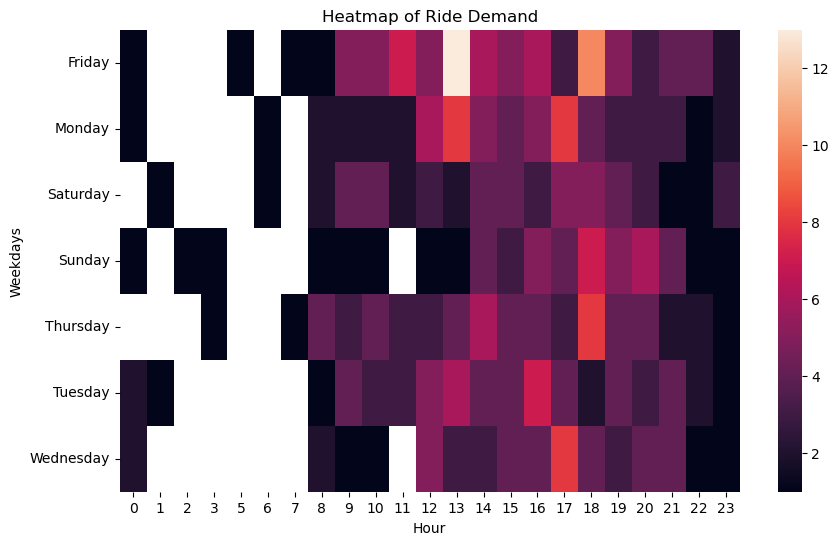

In [35]:
plt.figure(figsize=(10,6))
pivot = uber_df.pivot_table(index='weekday', columns='hour', aggfunc='size')
sns.heatmap(pivot)
plt.title("Heatmap of Ride Demand")
plt.xlabel('Hour')
plt.ylabel('Weekdays')
plt.show()

**Insight:**
*The heatmap shows that ride demand is concentrated during mid-day to evening hours (around 12 PM to 7 PM).Friday exhibits the highest ride intensity, especially during peak hours, indicating end-of-week travel demand.Early morning hours (midnight to 7 AM) have very low ride demand across all days.
Weekend days, particularly Sunday, show comparatively lower and more spread-out ride activity.This pattern suggests that ride demand is primarily driven by work-related commuting and scheduled activities.*

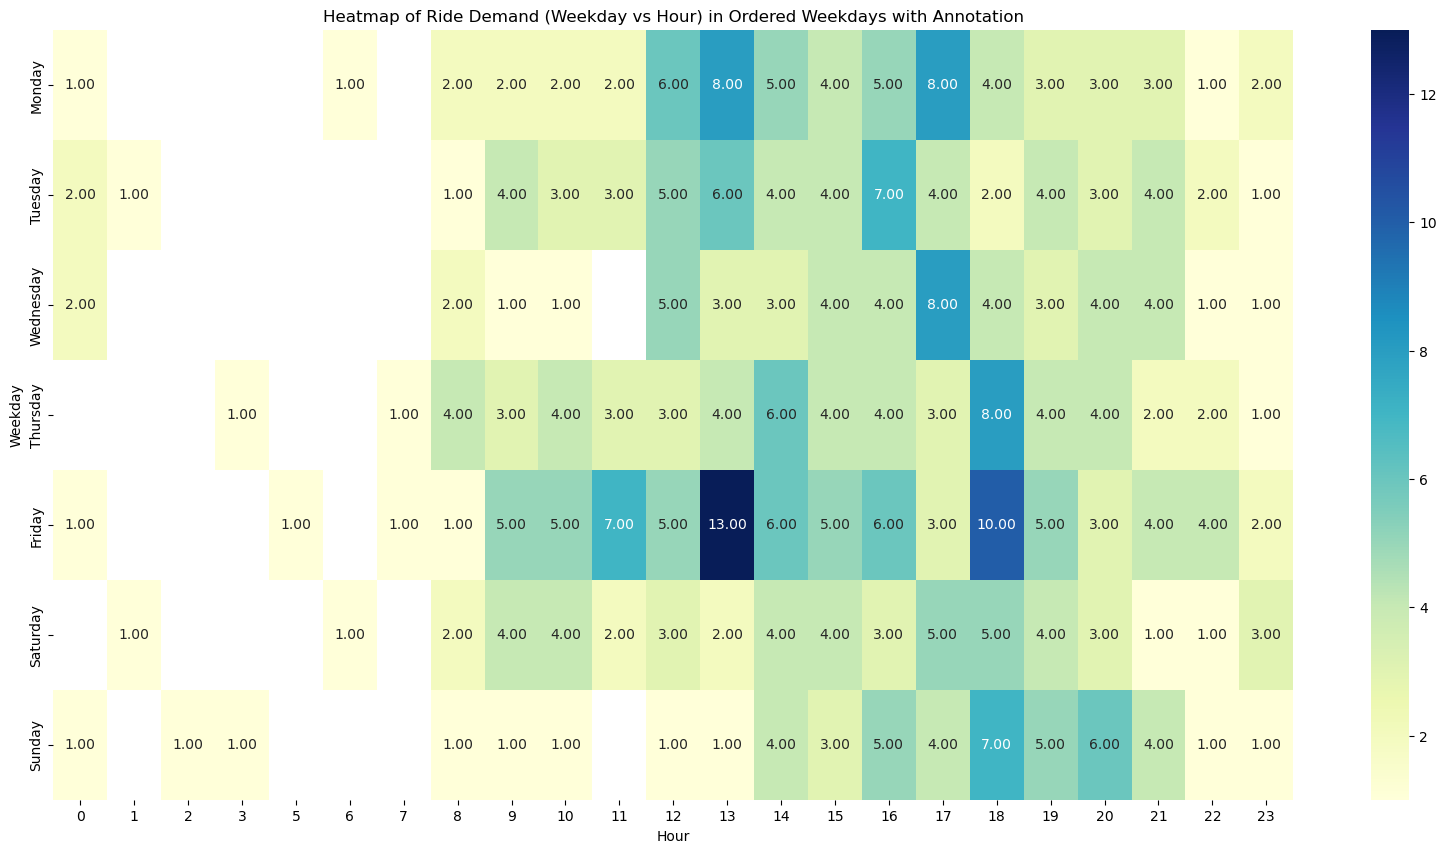

In [43]:
plt.figure(figsize=(20,10))
pivot = uber_df.pivot_table(index='weekday', columns='hour', aggfunc='size')
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(order)
sns.heatmap(pivot,annot=True, cmap='YlGnBu',fmt='.2f')
plt.title("Heatmap of Ride Demand (Weekday vs Hour) in Ordered Weekdays with Annotation")
plt.xlabel("Hour")
plt.ylabel("Weekday")
plt.show()

**Insight:**
*Ride demand is highest during afternoon and evening hours (12 PM to 6 PM).Friday shows the highest activity among all weekdays.Early morning hours have very low ride demand. Weekdays have higher ride activity compared to weekends. Weekend rides are fewer and more evenly spread across the day.*

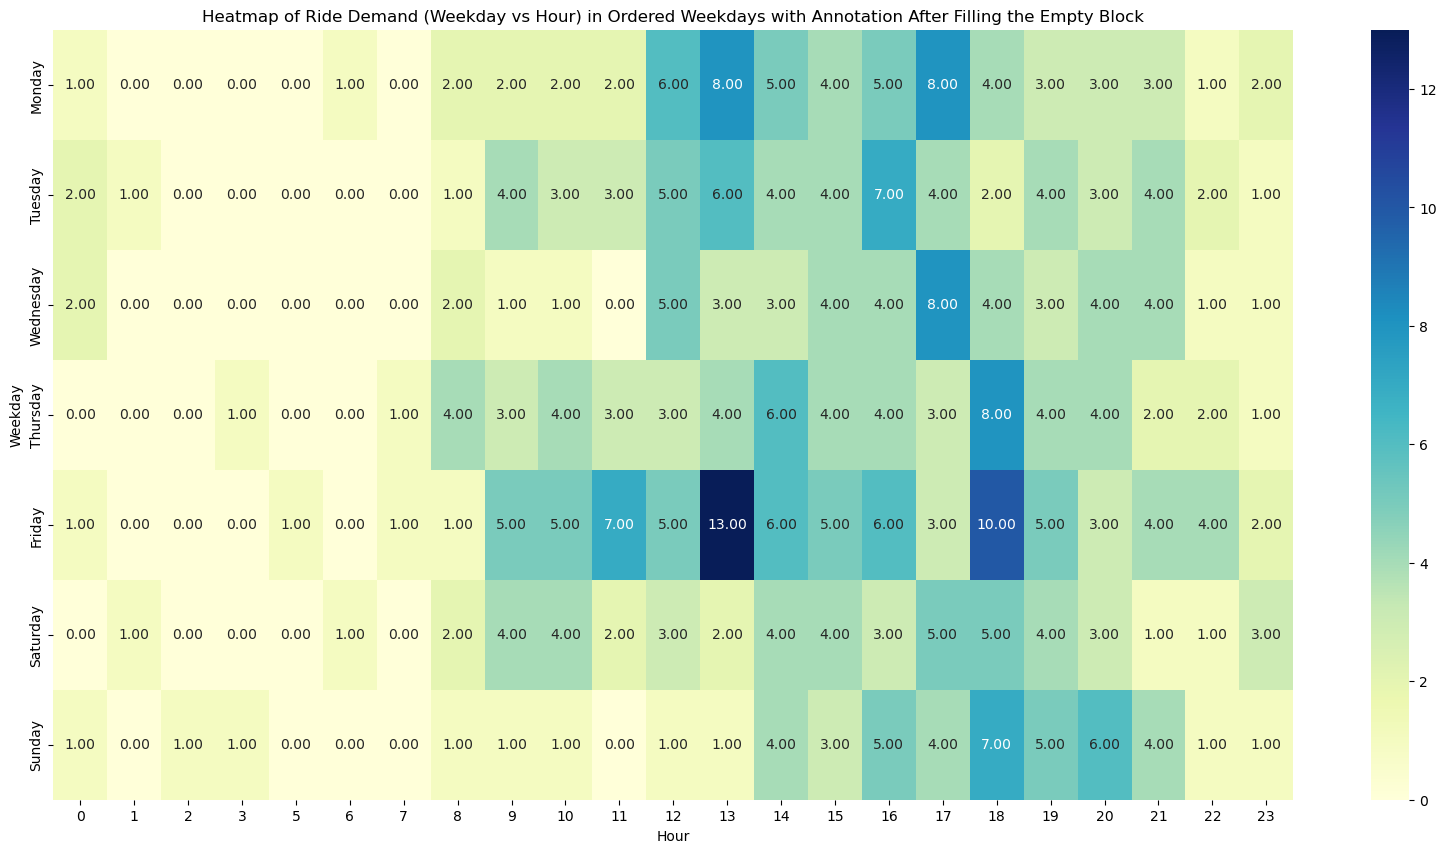

In [47]:
plt.figure(figsize=(20,10))
pivot = uber_df.pivot_table(index='weekday', columns='hour', aggfunc='size')
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(order)
pivot = pivot.fillna(0)
sns.heatmap(pivot,annot=True, cmap='YlGnBu',fmt='.2f')
plt.title("Heatmap of Ride Demand (Weekday vs Hour) in Ordered Weekdays with Annotation After Filling the Empty Block")
plt.xlabel("Hour")
plt.ylabel("Weekday")
plt.show()

**Insights:**
*After handling missing values using fillna(0), the heatmap clearly shows that ride demand peaks during weekday afternoons, especially on Fridays, while early mornings have minimal activity and weekends show lower overall demand.*

**Final Insights:**

*1. Ride demand peaks during afternoon and evening hours.*

*2. Weekdays have higher activity compared to weekends.*

*3. Friday shows the highest ride demand.*

*4. Business rides dominate the dataset.*

*5. Most rides are short-distance, but business trips vary more.*

*6. Meetings are the most common purpose of rides.*

**Conclusion:**

*This analysis shows that Uber rides are predominantly used for business purposes. Ride demand peaks during weekday afternoons and evenings, especially on Fridays. Most trips are short-distance, with business rides showing more variation. Overall, the data highlights strong work-related usage patterns and peak-time demand trends.*